# Di-4 GP Analysis with Cellpose Masks

Updated for Leica/LAS X TIFF exports named like:

`20260510 SKM-1 shCD59-3 5 uM Di-4.lif - Image003 - C=0.tif`

This notebook:
- pairs `C=0` and `C=1` channels by image field
- segments cells with Cellpose
- calculates **pixel-wise Di-4 GP inside each cell mask**
- exports numbered overlays so bad cells/debris can be excluded
- exports cell-level, field-level, and condition-level CSVs

For final GP quantification, use raw grayscale TIFFs exported with raw data, not RGB/LUT-rendered TIFFs.

## 1. Install packages

In [1]:
!pip install -q --upgrade cellpose tifffile scikit-image pandas matplotlib tqdm seaborn

## 2. Imports

In [2]:
import os
import re
import zipfile
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import tifffile as tiff
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects

from tqdm import tqdm
from skimage.measure import regionprops
from skimage.segmentation import find_boundaries
from skimage.filters import threshold_otsu

from cellpose import models

print("numpy:", np.__version__)

numpy: 2.4.4


## 3. Upload and unzip data

In [36]:
from google.colab import files

uploaded = files.upload()
zip_path = Path(list(uploaded.keys())[0])
print("Uploaded:", zip_path)

Saving 8-bit Images.zip to 8-bit Images.zip
Uploaded: 8-bit Images.zip


In [37]:
DATA_DIR = Path("/content/di4_data")

if DATA_DIR.exists():
    shutil.rmtree(DATA_DIR)

DATA_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(DATA_DIR)

print("Unzipped to:", DATA_DIR)
!find /content/di4_data -maxdepth 3 -type d

Unzipped to: /content/di4_data
/content/di4_data
/content/di4_data/__MACOSX
/content/di4_data/__MACOSX/8-bit Images
/content/di4_data/8-bit Images


## 4. Find TIFFs and build the file table

In [38]:
# Find TIFFs, excluding Mac/Google Drive hidden metadata files
tif_files = sorted([
    f for f in list(DATA_DIR.rglob("*.tif")) + list(DATA_DIR.rglob("*.tiff"))
    if not f.name.startswith("._")
    and not f.name.startswith(".")
    and "__MACOSX" not in str(f)
])

print("Candidate TIFF files:", len(tif_files))
for f in tif_files[:10]:
    print(f)

# Verify readable TIFFs
good_tifs = []
bad_tifs = []

for f in tif_files:
    try:
        _ = tiff.imread(f)
        good_tifs.append(f)
    except Exception as e:
        bad_tifs.append((f, str(e)))

tif_files = good_tifs

print("\nGood TIFFs:", len(good_tifs))
print("Bad TIFFs:", len(bad_tifs))
for f, err in bad_tifs[:20]:
    print("BAD:", f, "|", err)

Candidate TIFF files: 12
/content/di4_data/8-bit Images/20260510 HL-60 shCD59-3 5 uM Di-4.lif - Image003 - C=0.tif
/content/di4_data/8-bit Images/20260510 HL-60 shCD59-3 5 uM Di-4.lif - Image003 - C=1.tif
/content/di4_data/8-bit Images/20260510 HL-60 shCD59-7 5 uM Di-4.lif - Image002 - C=0.tif
/content/di4_data/8-bit Images/20260510 HL-60 shCD59-7 5 uM Di-4.lif - Image002 - C=1.tif
/content/di4_data/8-bit Images/20260510 HL-60 shNT 5 uM Di-4.lif - Image001 - C=0.tif
/content/di4_data/8-bit Images/20260510 HL-60 shNT 5 uM Di-4.lif - Image001 - C=1.tif
/content/di4_data/8-bit Images/20260510 SKM-1 shCD59-3 5 uM Di-4.lif - Image003 - C=0.tif
/content/di4_data/8-bit Images/20260510 SKM-1 shCD59-3 5 uM Di-4.lif - Image003 - C=1.tif
/content/di4_data/8-bit Images/20260510 SKM-1 shCD59-7 5 uM.lif - Image003 - C=0.tif
/content/di4_data/8-bit Images/20260510 SKM-1 shCD59-7 5 uM.lif - Image003 - C=1.tif

Good TIFFs: 12
Bad TIFFs: 0


In [44]:
def get_channel_number(filename):
    """Extract C=0 or C=1 from Leica/LAS X exported filename."""
    match = re.search(r"C=(\d+)", filename)
    if match is None:
        return None
    return int(match.group(1))


def get_image_number(filename):
    """Extract Image003, Image004, etc."""
    match = re.search(r"(Image\d+)", filename)
    if match is None:
        return None
    return match.group(1)


def get_cell_line(filename):
    name = Path(filename).name

    if "HL-60" in name or "HL60" in name:
        return "HL-60"
    elif "SKM-1" in name or "SKM1" in name:
        return "SKM-1"
    else:
        return "Unknown"


def get_condition(filename):
    name = Path(filename).name

    if "shCD59-3" in name or "sh3" in name:
        return "shCD59-3"
    elif "shCD59-7" in name or "sh7" in name:
        return "shCD59-7"
    elif "shNT" in name:
        return "shNT"
    else:
        return "Unknown"


def get_field_id(filename):
    """Unique image field identifier."""
    condition = get_condition(filename)
    image_num = get_image_number(filename)
    if image_num is None:
        image_num = Path(filename).stem
    return f"{condition}_{image_num}"


rows = []
for f in tif_files:
    channel = get_channel_number(f.name)
    image_num = get_image_number(f.name)
    condition = get_condition(f.name)
    field_id = get_field_id(f.name)

    if channel is None:
        continue

    rows.append({
    "path": f,
    "cell_line": get_cell_line(f.name),
    "condition": get_condition(f.name),
    "field_id": get_field_id(f.name),
    "image": image_num,
    "channel": channel,
    "filename": f.name
})

files_df = pd.DataFrame(rows)

display(files_df.head())
if not files_df.empty:
    display(files_df.groupby(["condition", "channel"]).size())
else:
    raise RuntimeError("files_df is empty. Check filename pattern and DATA_DIR.")

,path,cell_line,condition,field_id,image,channel,filename
0,/content/di4_data/8-bit Images/20260510 HL-60 ...,HL-60,shCD59-3,shCD59-3_Image003,Image003,0,20260510 HL-60 shCD59-3 5 uM Di-4.lif - Image0...
1,/content/di4_data/8-bit Images/20260510 HL-60 ...,HL-60,shCD59-3,shCD59-3_Image003,Image003,1,20260510 HL-60 shCD59-3 5 uM Di-4.lif - Image0...
2,/content/di4_data/8-bit Images/20260510 HL-60 ...,HL-60,shCD59-7,shCD59-7_Image002,Image002,0,20260510 HL-60 shCD59-7 5 uM Di-4.lif - Image0...
3,/content/di4_data/8-bit Images/20260510 HL-60 ...,HL-60,shCD59-7,shCD59-7_Image002,Image002,1,20260510 HL-60 shCD59-7 5 uM Di-4.lif - Image0...
4,/content/di4_data/8-bit Images/20260510 HL-60 ...,HL-60,shNT,shNT_Image001,Image001,0,20260510 HL-60 shNT 5 uM Di-4.lif - Image001 -...


condition  channel
shCD59-3   0          2
           1          2
shCD59-7   0          2
           1          2
shNT       0          2
           1          2
dtype: int64

## 5. Image reader and preview

In [45]:
def read_image(path, verbose=False):
    img = tiff.imread(path)
    img = np.asarray(img)

    if verbose:
        print(Path(path).name, "shape:", img.shape, "dtype:", img.dtype)

    # Ideal case: raw grayscale image
    if img.ndim == 2:
        return img.astype(np.float32)

    # RGB/RGBA rendered image: use strongest RGB channel
    # Useful for troubleshooting, but raw grayscale is better for final GP.
    if img.ndim == 3 and img.shape[-1] in [3, 4]:
        rgb = img[..., :3].astype(np.float32)
        channel_sums = rgb.reshape(-1, 3).sum(axis=0)
        best_channel = int(np.argmax(channel_sums))
        if verbose:
            print("Using RGB channel:", best_channel)
        return rgb[..., best_channel].astype(np.float32)

    # C x Y x X
    if img.ndim == 3 and img.shape[0] <= 4:
        return img.max(axis=0).astype(np.float32)

    # Z x Y x X
    if img.ndim == 3:
        return img.max(axis=0).astype(np.float32)

    # Z x Y x X x RGB
    if img.ndim == 4 and img.shape[-1] in [3, 4]:
        rgb = img[..., :3].astype(np.float32)
        gray = rgb.max(axis=-1)   # Z x Y x X
        return gray.max(axis=0).astype(np.float32)

    raise ValueError(f"Unsupported image shape for {path}: {img.shape}")


def normalize_img(img, lower=1, upper=99):
    img = img.astype(np.float32)
    lo, hi = np.percentile(img, [lower, upper])
    if hi <= lo:
        return np.zeros_like(img, dtype=np.float32)
    out = (img - lo) / (hi - lo)
    return np.clip(out, 0, 1).astype(np.float32)

shCD59-3
shCD59-3_Image003


,path,cell_line,condition,field_id,image,channel,filename
0,/content/di4_data/8-bit Images/20260510 HL-60 ...,HL-60,shCD59-3,shCD59-3_Image003,Image003,0,20260510 HL-60 shCD59-3 5 uM Di-4.lif - Image0...
6,/content/di4_data/8-bit Images/20260510 SKM-1 ...,SKM-1,shCD59-3,shCD59-3_Image003,Image003,0,20260510 SKM-1 shCD59-3 5 uM Di-4.lif - Image0...
1,/content/di4_data/8-bit Images/20260510 HL-60 ...,HL-60,shCD59-3,shCD59-3_Image003,Image003,1,20260510 HL-60 shCD59-3 5 uM Di-4.lif - Image0...
7,/content/di4_data/8-bit Images/20260510 SKM-1 ...,SKM-1,shCD59-3,shCD59-3_Image003,Image003,1,20260510 SKM-1 shCD59-3 5 uM Di-4.lif - Image0...


20260510 HL-60 shCD59-3 5 uM Di-4.lif - Image003 - C=0.tif shape: (512, 512) dtype: uint8
C=0: min=0.00, max=255.00, p99=210.00
20260510 SKM-1 shCD59-3 5 uM Di-4.lif - Image003 - C=0.tif shape: (512, 512) dtype: uint8
C=0: min=0.00, max=255.00, p99=122.00
20260510 HL-60 shCD59-3 5 uM Di-4.lif - Image003 - C=1.tif shape: (512, 512) dtype: uint8
C=1: min=0.00, max=255.00, p99=255.00
20260510 SKM-1 shCD59-3 5 uM Di-4.lif - Image003 - C=1.tif shape: (512, 512) dtype: uint8
C=1: min=0.00, max=255.00, p99=255.00


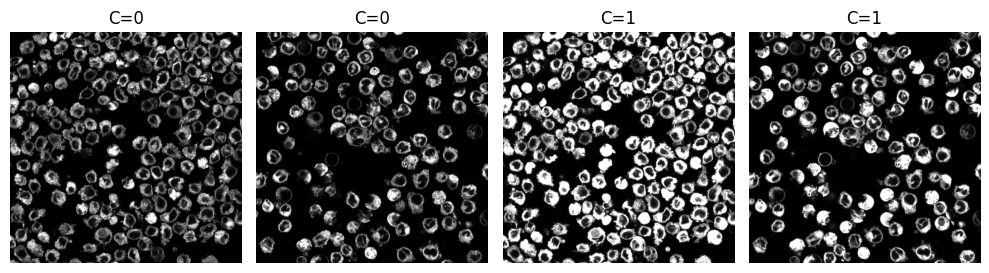

In [46]:
# Choose one field to preview
example_condition = files_df["condition"].unique()[0]
example_field = files_df.loc[files_df["condition"] == example_condition, "field_id"].iloc[0]

example_group = files_df[
    (files_df["condition"] == example_condition) &
    (files_df["field_id"] == example_field)
].sort_values("channel")

print(example_condition)
print(example_field)
display(example_group)

plt.figure(figsize=(10, 5))

for i, row in enumerate(example_group.itertuples(), start=1):
    img = read_image(row.path, verbose=True)
    print(f"C={row.channel}: min={np.min(img):.2f}, max={np.max(img):.2f}, p99={np.percentile(img, 99):.2f}")

    plt.subplot(1, len(example_group), i)
    plt.imshow(normalize_img(img), cmap="gray")
    plt.title(f"C={row.channel}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 6. Set channel mapping and analysis parameters

In [47]:
# Usually for your Di-4 export:
# C=0 = ordered channel; C=1 = disordered channel.
ORDERED_CHANNEL = 0
DISORDERED_CHANNEL = 1

# Use None to segment from ordered + disordered.
SEGMENTATION_CHANNEL = None

DIAMETER = 15
MIN_AREA = 5
MAX_AREA = 5000

# Use 1.0 for initial analysis. Replace with calibrated G factor if available.
G_FACTOR = 1.0

BACKGROUND_MODE = "otsu"

# Analyze only Di-4-positive pixels inside each Cellpose mask.
INTENSITY_THRESHOLD_MODE = "otsu"  # "otsu", "percentile", or "none"
MIN_VALID_PIXELS = 20

## 7. Helper functions for GP, masks, overlays, and numbered QC images

In [48]:
def estimate_background(img, mode="otsu"):
    img = img.astype(np.float32)

    if mode == "none":
        return 0.0

    if mode == "median":
        return float(np.median(img))

    if mode == "otsu":
        try:
            thresh = threshold_otsu(img)
            bg_pixels = img[img < thresh]
            if bg_pixels.size == 0:
                return float(np.median(img))
            return float(np.median(bg_pixels))
        except Exception:
            return float(np.median(img))

    raise ValueError("background mode must be: none, median, or otsu")


def remove_small_large_masks(mask, min_area=5, max_area=5000):
    cleaned = np.zeros_like(mask, dtype=np.int32)
    new_id = 1

    for cell_id in np.unique(mask):
        if cell_id == 0:
            continue

        area = np.sum(mask == cell_id)
        if min_area <= area <= max_area:
            cleaned[mask == cell_id] = new_id
            new_id += 1

    return cleaned


def calculate_pixelwise_gp_image(ordered, disordered, g_factor=1.0, background_mode="otsu"):
    """
    Pixel-wise Di-4 GP:
    GP = (ordered - G*disordered) / (ordered + G*disordered)
    """
    ordered_bg = estimate_background(ordered, background_mode)
    disordered_bg = estimate_background(disordered, background_mode)

    ordered_corr = ordered.astype(np.float32) - ordered_bg
    disordered_corr = disordered.astype(np.float32) - disordered_bg

    ordered_corr[ordered_corr < 0] = 0
    disordered_corr[disordered_corr < 0] = 0

    numerator = ordered_corr - g_factor * disordered_corr
    denominator = ordered_corr + g_factor * disordered_corr

    gp_img = np.full_like(ordered_corr, np.nan, dtype=np.float32)
    valid = denominator > 0
    gp_img[valid] = numerator[valid] / denominator[valid]

    total_di4 = ordered_corr + disordered_corr

    return gp_img, ordered_corr, disordered_corr, total_di4, ordered_bg, disordered_bg


def compute_di4_metrics_per_cell(
    mask,
    ordered,
    disordered,
    g_factor=1.0,
    background_mode="otsu",
    intensity_threshold_mode="otsu",
    min_valid_pixels=20
):
    """
    Better Di-4 quantification:
    - background corrects ordered/disordered channels
    - calculates pixel-wise GP
    - thresholds total Di-4 signal to remove background/low-SNR pixels
    - summarizes valid GP pixels per Cellpose cell
    """
    gp_img, ordered_corr, disordered_corr, total_di4, ordered_bg, disordered_bg = calculate_pixelwise_gp_image(
        ordered,
        disordered,
        g_factor=g_factor,
        background_mode=background_mode
    )

    positive_total = total_di4[total_di4 > 0]

    if positive_total.size == 0:
        intensity_threshold = 0.0
    elif intensity_threshold_mode == "otsu":
        try:
            intensity_threshold = float(threshold_otsu(positive_total))
        except Exception:
            intensity_threshold = float(np.percentile(positive_total, 20))
    elif intensity_threshold_mode == "percentile":
        intensity_threshold = float(np.percentile(positive_total, 20))
    elif intensity_threshold_mode == "none":
        intensity_threshold = 0.0
    else:
        raise ValueError("intensity_threshold_mode must be: otsu, percentile, or none")

    valid_di4 = total_di4 > intensity_threshold

    rows = []

    for region in regionprops(mask):
        cell_id = region.label
        coords = region.coords

        rr = coords[:, 0]
        cc = coords[:, 1]

        cell_valid = valid_di4[rr, cc] & np.isfinite(gp_img[rr, cc])

        n_total_pixels = len(rr)
        n_valid_pixels = int(np.sum(cell_valid))

        if n_valid_pixels < min_valid_pixels:
            continue

        gp_vals = gp_img[rr, cc][cell_valid]
        ordered_vals = ordered_corr[rr, cc][cell_valid]
        disordered_vals = disordered_corr[rr, cc][cell_valid]
        total_vals = total_di4[rr, cc][cell_valid]

        mean_disordered = float(np.nanmean(disordered_vals))
        mean_ordered = float(np.nanmean(ordered_vals))

        rows.append({
            "cell_id": int(cell_id),
            "area_px": float(region.area),
            "valid_di4_area_px": int(n_valid_pixels),
            "fraction_valid_di4": float(n_valid_pixels / n_total_pixels),
            "centroid_y": float(region.centroid[0]),
            "centroid_x": float(region.centroid[1]),

            "mean_gp_pixelwise": float(np.nanmean(gp_vals)),
            "median_gp_pixelwise": float(np.nanmedian(gp_vals)),
            "sd_gp_pixelwise": float(np.nanstd(gp_vals)),

            "mean_ordered": mean_ordered,
            "mean_disordered": mean_disordered,
            "mean_total_di4": float(np.nanmean(total_vals)),
            "integrated_total_di4": float(np.nansum(total_vals)),

            "ordered_disordered_ratio": (
                mean_ordered / mean_disordered if mean_disordered != 0 else np.nan
            ),

            "ordered_background": float(ordered_bg),
            "disordered_background": float(disordered_bg),
            "di4_intensity_threshold": float(intensity_threshold)
        })

    return pd.DataFrame(rows), gp_img, valid_di4


def make_rgb_overlay(ordered, disordered, mask):
    """
    Green = ordered, red = disordered, white = Cellpose boundary.
    """
    ordered_norm = normalize_img(ordered)
    disordered_norm = normalize_img(disordered)

    rgb = np.zeros((*ordered.shape, 3), dtype=np.float32)
    rgb[..., 0] = disordered_norm
    rgb[..., 1] = ordered_norm

    boundaries = find_boundaries(mask, mode="outer")
    rgb[boundaries] = [1, 1, 1]

    return rgb


def save_numbered_overlay(ordered, disordered, mask, out_path, title="", fontsize=7):
    overlay = make_rgb_overlay(ordered, disordered, mask)

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(overlay)
    ax.set_title(title, fontsize=10)
    ax.axis("off")

    for region in regionprops(mask):
        y, x = region.centroid
        txt = ax.text(
            x, y, str(region.label),
            color="yellow",
            fontsize=fontsize,
            ha="center",
            va="center"
        )
        txt.set_path_effects([
            path_effects.Stroke(linewidth=1.5, foreground="black"),
            path_effects.Normal()
        ])

    plt.tight_layout()
    plt.savefig(out_path, dpi=300)
    plt.close()


def save_gp_image(gp_img, out_path, title="", vmin=-1, vmax=1):
    plt.figure(figsize=(8, 8))
    plt.imshow(gp_img, cmap="turbo", vmin=vmin, vmax=vmax)
    plt.colorbar(label="Di-4 GP")
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(out_path, dpi=300)
    plt.close()

## 8. Load Cellpose model

In [49]:
# Runtime → Change runtime type → T4 GPU is recommended.
try:
    model = models.CellposeModel(gpu=True, pretrained_model="cyto3")
    print("Loaded Cellpose with GPU=True")
except Exception as e:
    print("GPU model load failed, falling back to CPU:", e)
    model = models.CellposeModel(gpu=False, pretrained_model="cyto3")

Loaded Cellpose with GPU=True


## 9. Test Cellpose on one field before batch processing

Raw masks: 210
Filtered masks: 210


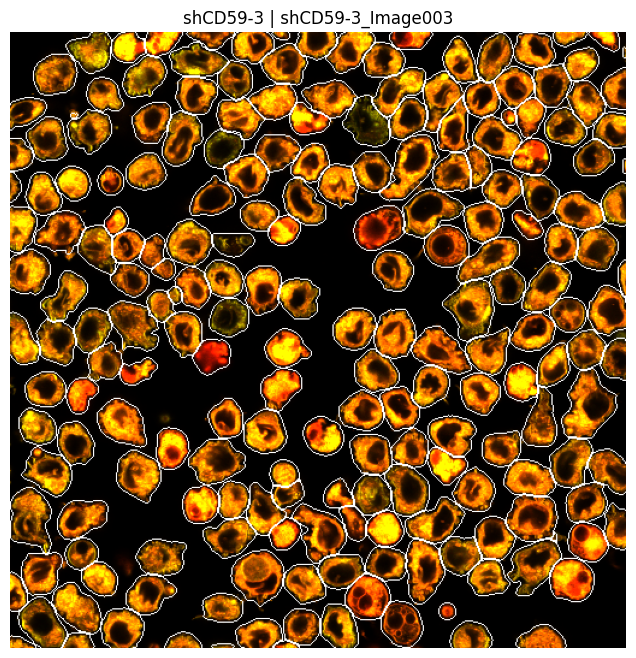

In [50]:
test_group = example_group.copy()

ordered_path = test_group.loc[test_group["channel"] == ORDERED_CHANNEL, "path"].iloc[0]
disordered_path = test_group.loc[test_group["channel"] == DISORDERED_CHANNEL, "path"].iloc[0]

ordered = read_image(ordered_path)
disordered = read_image(disordered_path)

if SEGMENTATION_CHANNEL is not None:
    seg_path = test_group.loc[test_group["channel"] == SEGMENTATION_CHANNEL, "path"].iloc[0]
    seg_img = read_image(seg_path)
else:
    seg_img = ordered + disordered

seg_img_norm = normalize_img(seg_img)

masks, flows, styles = model.eval(
    seg_img_norm,
    diameter=DIAMETER,
    channels=[0, 0],
    cellprob_threshold=-2,
    flow_threshold=1
)

print("Raw masks:", int(masks.max()))

masks_filtered = remove_small_large_masks(
    masks,
    min_area=MIN_AREA,
    max_area=MAX_AREA
)

print("Filtered masks:", int(masks_filtered.max()))

overlay = make_rgb_overlay(ordered, disordered, masks_filtered)

plt.figure(figsize=(8, 8))
plt.imshow(overlay)
plt.title(f"{example_condition} | {example_field}")
plt.axis("off")
plt.show()

,cell_id,area_px,valid_di4_area_px,fraction_valid_di4,centroid_y,centroid_x,mean_gp_pixelwise,median_gp_pixelwise,sd_gp_pixelwise,mean_ordered,mean_disordered,mean_total_di4,integrated_total_di4,ordered_disordered_ratio,ordered_background,disordered_background,di4_intensity_threshold
0,1,867.0,460,0.530565,15.683968,67.412918,-0.245768,-0.234375,0.106957,119.873917,194.684784,314.558685,144697.0,0.615733,3.0,7.0,196.896484
1,2,538.0,417,0.775093,12.115242,97.717472,-0.199404,-0.097345,0.232132,177.340530,242.992813,420.333344,175279.0,0.729818,3.0,7.0,196.896484
2,3,473.0,364,0.769556,8.308668,125.004228,-0.282992,-0.238454,0.214833,148.310440,244.491760,392.802185,142980.0,0.606607,3.0,7.0,196.896484
3,4,347.0,130,0.374640,4.829971,167.040346,-0.446489,-0.457596,0.061779,77.630768,200.800003,278.430756,36196.0,0.386607,3.0,7.0,196.896484
4,5,727.0,400,0.550206,11.221458,200.984869,-0.339007,-0.364049,0.127225,119.294998,230.705002,350.000000,140000.0,0.517089,3.0,7.0,196.896484


,area_px,valid_di4_area_px,fraction_valid_di4,mean_gp_pixelwise,median_gp_pixelwise,mean_ordered,mean_disordered,mean_total_di4
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,782.214634,370.600000,0.480634,-0.371439,-0.379135,103.094499,215.965840,319.060339
std,276.039307,162.047972,0.146878,0.072069,0.080972,19.321058,20.327014,34.247450
min,69.000000,26.000000,0.047266,-0.782483,-0.810219,30.031963,129.372543,231.078430
25%,630.000000,262.000000,0.387685,-0.398910,-0.413105,90.920586,202.908051,295.934418
50%,815.000000,379.000000,0.477765,-0.369865,-0.381295,102.071426,221.528824,322.374298
75%,937.000000,469.000000,0.574099,-0.344906,-0.347826,112.436623,230.472000,340.432495
max,1674.000000,789.000000,0.779592,-0.120429,-0.097345,177.340530,245.794205,420.333344


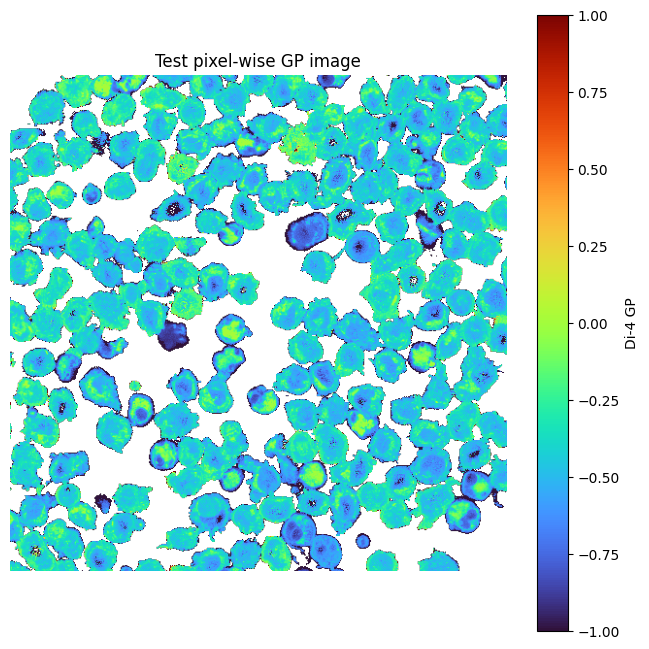

In [51]:
test_df, test_gp_img, test_valid_di4 = compute_di4_metrics_per_cell(
    masks_filtered,
    ordered,
    disordered,
    g_factor=G_FACTOR,
    background_mode=BACKGROUND_MODE,
    intensity_threshold_mode=INTENSITY_THRESHOLD_MODE,
    min_valid_pixels=MIN_VALID_PIXELS
)

display(test_df.head())
display(test_df[[
    "area_px",
    "valid_di4_area_px",
    "fraction_valid_di4",
    "mean_gp_pixelwise",
    "median_gp_pixelwise",
    "mean_ordered",
    "mean_disordered",
    "mean_total_di4"
]].describe())

plt.figure(figsize=(8, 8))
plt.imshow(test_gp_img, cmap="turbo", vmin=-1, vmax=1)
plt.colorbar(label="Di-4 GP")
plt.title("Test pixel-wise GP image")
plt.axis("off")
plt.show()

## 10. Batch process all fields

In [52]:
OUTPUT_DIR = Path("/content/di4_gp_results")
MASK_DIR = OUTPUT_DIR / "masks_label_tiffs"
OVERLAY_DIR = OUTPUT_DIR / "numbered_overlays"
GP_IMAGE_DIR = OUTPUT_DIR / "gp_images"

OUTPUT_DIR.mkdir(exist_ok=True)
MASK_DIR.mkdir(exist_ok=True)
OVERLAY_DIR.mkdir(exist_ok=True)
GP_IMAGE_DIR.mkdir(exist_ok=True)

all_cell_results = []

grouped = files_df.groupby(["cell_line", "condition", "field_id"])

for (cell_line, condition, field_id), group in tqdm(grouped, total=len(grouped)):
    ordered_rows = group[group["channel"] == ORDERED_CHANNEL]
    disordered_rows = group[group["channel"] == DISORDERED_CHANNEL]

    if ordered_rows.empty or disordered_rows.empty:
        print("Skipping missing ordered/disordered:", cell_line, condition, field_id)
        continue

    ordered_path = ordered_rows.iloc[0]["path"]
    disordered_path = disordered_rows.iloc[0]["path"]

    ordered = read_image(ordered_path)
    disordered = read_image(disordered_path)

    if ordered.shape != disordered.shape:
        print("Skipping shape mismatch:", cell_line, condition, field_id)
        continue

    if SEGMENTATION_CHANNEL is not None:
        seg_rows = group[group["channel"] == SEGMENTATION_CHANNEL]

        if seg_rows.empty:
            print("Skipping missing segmentation channel:", cell_line, condition, field_id)
            continue

        seg_img = read_image(seg_rows.iloc[0]["path"])
    else:
        seg_img = ordered + disordered

    seg_img_norm = normalize_img(seg_img)

    masks, flows, styles = model.eval(
        seg_img_norm,
        diameter=DIAMETER,
        channels=[0, 0],
        cellprob_threshold=-2,
        flow_threshold=1
    )

    raw_n = int(masks.max())

    masks_filtered = remove_small_large_masks(
        masks,
        min_area=MIN_AREA,
        max_area=MAX_AREA
    )

    filtered_n = int(masks_filtered.max())

    if filtered_n == 0:
        print(f"No masks after filtering: {cell_line} | {condition} | {field_id} | raw={raw_n}")
        continue

    cell_df, gp_img, valid_di4 = compute_di4_metrics_per_cell(
        masks_filtered,
        ordered,
        disordered,
        g_factor=G_FACTOR,
        background_mode=BACKGROUND_MODE,
        intensity_threshold_mode="otsu",
        min_valid_pixels=20
    )

    if cell_df.empty:
        print(f"No cells quantified: {cell_line} | {condition} | {field_id} | raw={raw_n}, filtered={filtered_n}")
        continue

    cell_df["cell_line"] = cell_line
    cell_df["condition"] = condition
    cell_df["field_id"] = field_id
    cell_df["raw_masks"] = raw_n
    cell_df["filtered_masks"] = filtered_n
    cell_df["ordered_file"] = Path(ordered_path).name
    cell_df["disordered_file"] = Path(disordered_path).name
    cell_df["ordered_channel"] = ORDERED_CHANNEL
    cell_df["disordered_channel"] = DISORDERED_CHANNEL
    cell_df["segmentation_channel"] = (
        SEGMENTATION_CHANNEL if SEGMENTATION_CHANNEL is not None
        else "ordered_plus_disordered"
    )

    all_cell_results.append(cell_df)

    safe_name = re.sub(
        r"[^A-Za-z0-9_.-]+",
        "_",
        f"{cell_line}_{condition}_{field_id}"
    )

    tiff.imwrite(
        MASK_DIR / f"{safe_name}_label_mask.tif",
        masks_filtered.astype(np.uint16)
    )

    save_numbered_overlay(
        ordered,
        disordered,
        masks_filtered,
        OVERLAY_DIR / f"{safe_name}_numbered_overlay.png",
        title=f"{cell_line} | {condition} | {field_id}"
    )

    save_gp_image(
        gp_img,
        GP_IMAGE_DIR / f"{safe_name}_gp_image.png",
        title=f"{cell_line} | {condition} | {field_id}",
        vmin=-1,
        vmax=1
    )

print("Number of quantified fields:", len(all_cell_results))

100%|██████████| 6/6 [00:20<00:00,  3.40s/it]

Number of quantified fields: 6


## 11. Save cell-level, field-level, and condition-level CSVs

In [53]:
if len(all_cell_results) == 0:
    raise RuntimeError("No cells were quantified. Check Cellpose masks and channel mapping.")

cell_level_gp = pd.concat(all_cell_results, ignore_index=True)

# Optional: create image column if it does not exist
if "image" not in cell_level_gp.columns:
    cell_level_gp["image"] = cell_level_gp["field_id"]

first_cols = [
    "cell_line",
    "condition",
    "field_id",
    "image",
    "cell_id",
    "area_px",
    "valid_di4_area_px",
    "fraction_valid_di4",
    "centroid_x",
    "centroid_y",
    "mean_gp_pixelwise",
    "median_gp_pixelwise",
    "sd_gp_pixelwise",
    "mean_ordered",
    "mean_disordered",
    "mean_total_di4",
    "integrated_total_di4",
    "ordered_disordered_ratio"
]

# Only keep columns that actually exist
first_cols_existing = [c for c in first_cols if c in cell_level_gp.columns]
other_cols = [c for c in cell_level_gp.columns if c not in first_cols_existing]

cell_level_gp = cell_level_gp[first_cols_existing + other_cols]

cell_csv = OUTPUT_DIR / "cell_level_gp_values.csv"
cell_level_gp.to_csv(cell_csv, index=False)

field_summary = (
    cell_level_gp
    .groupby(["cell_line", "condition", "field_id"])
    .agg(
        n_cells=("cell_id", "count"),
        field_mean_gp=("median_gp_pixelwise", "mean"),
        field_median_gp=("median_gp_pixelwise", "median"),
        mean_total_di4=("mean_total_di4", "mean"),
        mean_fraction_valid_di4=("fraction_valid_di4", "mean")
    )
    .reset_index()
)

field_summary_csv = OUTPUT_DIR / "field_level_gp_summary.csv"
field_summary.to_csv(field_summary_csv, index=False)

condition_summary = (
    field_summary
    .groupby(["cell_line", "condition"])
    .agg(
        n_fields=("field_id", "count"),
        total_cells=("n_cells", "sum"),
        mean_field_gp=("field_mean_gp", "mean"),
        sd_field_gp=("field_mean_gp", "std"),
        sem_field_gp=("field_mean_gp", lambda x: x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan)
    )
    .reset_index()
)

condition_summary_csv = OUTPUT_DIR / "condition_level_gp_summary.csv"
condition_summary.to_csv(condition_summary_csv, index=False)

print("Saved:")
print(cell_csv)
print(field_summary_csv)
print(condition_summary_csv)

print("\nColumns in cell_level_gp:")
print(list(cell_level_gp.columns))

display(cell_level_gp.head())
display(field_summary.head())
display(condition_summary)

Saved:
/content/di4_gp_results/cell_level_gp_values.csv
/content/di4_gp_results/field_level_gp_summary.csv
/content/di4_gp_results/condition_level_gp_summary.csv

Columns in cell_level_gp:
['cell_line', 'condition', 'field_id', 'image', 'cell_id', 'area_px', 'valid_di4_area_px', 'fraction_valid_di4', 'centroid_x', 'centroid_y', 'mean_gp_pixelwise', 'median_gp_pixelwise', 'sd_gp_pixelwise', 'mean_ordered', 'mean_disordered', 'mean_total_di4', 'integrated_total_di4', 'ordered_disordered_ratio', 'ordered_background', 'disordered_background', 'di4_intensity_threshold', 'raw_masks', 'filtered_masks', 'ordered_file', 'disordered_file', 'ordered_channel', 'disordered_channel', 'segmentation_channel']


,cell_line,condition,field_id,image,cell_id,area_px,valid_di4_area_px,fraction_valid_di4,centroid_x,centroid_y,...,ordered_background,disordered_background,di4_intensity_threshold,raw_masks,filtered_masks,ordered_file,disordered_file,ordered_channel,disordered_channel,segmentation_channel
0,HL-60,shCD59-3,shCD59-3_Image003,shCD59-3_Image003,1,867.0,460,0.530565,67.412918,15.683968,...,3.0,7.0,196.896484,210,210,20260510 HL-60 shCD59-3 5 uM Di-4.lif - Image0...,20260510 HL-60 shCD59-3 5 uM Di-4.lif - Image0...,0,1,ordered_plus_disordered
1,HL-60,shCD59-3,shCD59-3_Image003,shCD59-3_Image003,2,538.0,417,0.775093,97.717472,12.115242,...,3.0,7.0,196.896484,210,210,20260510 HL-60 shCD59-3 5 uM Di-4.lif - Image0...,20260510 HL-60 shCD59-3 5 uM Di-4.lif - Image0...,0,1,ordered_plus_disordered
2,HL-60,shCD59-3,shCD59-3_Image003,shCD59-3_Image003,3,473.0,364,0.769556,125.004228,8.308668,...,3.0,7.0,196.896484,210,210,20260510 HL-60 shCD59-3 5 uM Di-4.lif - Image0...,20260510 HL-60 shCD59-3 5 uM Di-4.lif - Image0...,0,1,ordered_plus_disordered
3,HL-60,shCD59-3,shCD59-3_Image003,shCD59-3_Image003,4,347.0,130,0.374640,167.040346,4.829971,...,3.0,7.0,196.896484,210,210,20260510 HL-60 shCD59-3 5 uM Di-4.lif - Image0...,20260510 HL-60 shCD59-3 5 uM Di-4.lif - Image0...,0,1,ordered_plus_disordered
4,HL-60,shCD59-3,shCD59-3_Image003,shCD59-3_Image003,5,727.0,400,0.550206,200.984869,11.221458,...,3.0,7.0,196.896484,210,210,20260510 HL-60 shCD59-3 5 uM Di-4.lif - Image0...,20260510 HL-60 shCD59-3 5 uM Di-4.lif - Image0...,0,1,ordered_plus_disordered


,cell_line,condition,field_id,n_cells,field_mean_gp,field_median_gp,mean_total_di4,mean_fraction_valid_di4
0,HL-60,shCD59-3,shCD59-3_Image003,205,-0.379135,-0.381295,319.060339,0.480634
1,HL-60,shCD59-7,shCD59-7_Image002,174,-0.387432,-0.393939,322.984651,0.471393
2,HL-60,shNT,shNT_Image001,284,-0.325869,-0.325199,283.174866,0.325084
3,SKM-1,shCD59-3,shCD59-3_Image003,131,-0.492950,-0.464174,263.686433,0.426732
4,SKM-1,shCD59-7,shCD59-7_Image003,184,-0.448718,-0.449922,263.260261,0.356685


,cell_line,condition,n_fields,total_cells,mean_field_gp,sd_field_gp,sem_field_gp
0,HL-60,shCD59-3,1,205,-0.379135,NaN,NaN
1,HL-60,shCD59-7,1,174,-0.387432,NaN,NaN
2,HL-60,shNT,1,284,-0.325869,NaN,NaN
3,SKM-1,shCD59-3,1,131,-0.492950,NaN,NaN
4,SKM-1,shCD59-7,1,184,-0.448718,NaN,NaN
5,SKM-1,shNT,1,140,-0.315250,NaN,NaN


## 12. Create exclusion template for manual QC

In [54]:
exclusion_template = cell_level_gp[
    [
        "condition",
        "field_id",
        "image",
        "cell_id",
        "area_px",
        "valid_di4_area_px",
        "fraction_valid_di4",
        "mean_gp_pixelwise",
        "median_gp_pixelwise",
        "mean_total_di4"
    ]
].copy()

exclusion_template["exclude"] = ""
exclusion_template["reason"] = ""

exclusion_csv = OUTPUT_DIR / "cell_exclusion_template.csv"
exclusion_template.to_csv(exclusion_csv, index=False)

print("Saved exclusion template:", exclusion_csv)
display(exclusion_template.head())

Saved exclusion template: /content/di4_gp_results/cell_exclusion_template.csv


,condition,field_id,image,cell_id,area_px,valid_di4_area_px,fraction_valid_di4,mean_gp_pixelwise,median_gp_pixelwise,mean_total_di4,exclude,reason
0,shCD59-3,shCD59-3_Image003,shCD59-3_Image003,1,867.0,460,0.530565,-0.245768,-0.234375,314.558685,,
1,shCD59-3,shCD59-3_Image003,shCD59-3_Image003,2,538.0,417,0.775093,-0.199404,-0.097345,420.333344,,
2,shCD59-3,shCD59-3_Image003,shCD59-3_Image003,3,473.0,364,0.769556,-0.282992,-0.238454,392.802185,,
3,shCD59-3,shCD59-3_Image003,shCD59-3_Image003,4,347.0,130,0.374640,-0.446489,-0.457596,278.430756,,
4,shCD59-3,shCD59-3_Image003,shCD59-3_Image003,5,727.0,400,0.550206,-0.339007,-0.364049,350.000000,,


## 13. Plot QC and GP by condition

/tmp/ipykernel_1824/3918479300.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


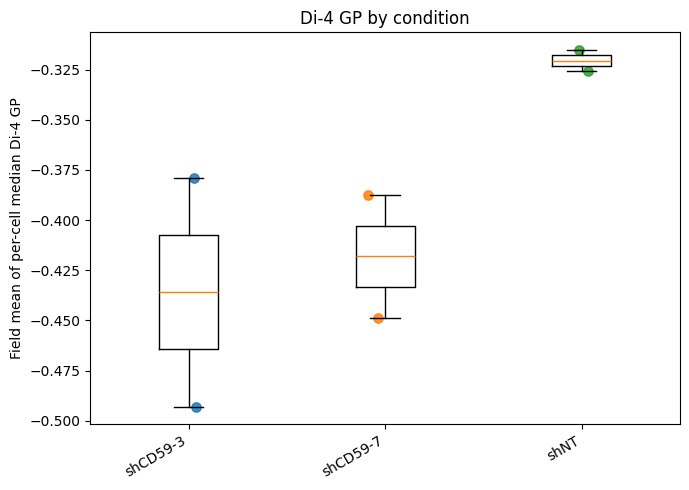

In [55]:
import numpy as np
import matplotlib.pyplot as plt

metric = "field_mean_gp"   # change to "field_median_gp" if preferred

plot_df = field_summary.dropna(subset=[metric]).copy()
conditions = plot_df["condition"].unique()

data = [
    plot_df.loc[plot_df["condition"] == cond, metric].values
    for cond in conditions
]

plt.figure(figsize=(7, 5))

plt.boxplot(
    data,
    labels=conditions,
    showfliers=False
)

for i, vals in enumerate(data, start=1):
    x = np.random.normal(i, 0.04, size=len(vals))
    plt.scatter(x, vals, s=45, alpha=0.85)

plt.xticks(rotation=30, ha="right")
plt.ylabel("Field mean of per-cell median Di-4 GP")
plt.xlabel("")
plt.title("Di-4 GP by condition")
plt.tight_layout()
plt.show()

## 14. Optional: upload edited exclusion CSV and generate cleaned summaries

In [ ]:
# Optional cleaning step. Run only after editing and uploading the exclusion CSV.
from google.colab import files

uploaded_exclusion = files.upload()
exclusion_file = list(uploaded_exclusion.keys())[0]

exclusions = pd.read_csv(exclusion_file)
exclusions["exclude"] = exclusions["exclude"].astype(str).str.lower().str.strip()

bad_cells = exclusions[exclusions["exclude"].isin(["yes", "y", "true", "1"])][
    ["condition", "field_id", "cell_id"]
].copy()

cell_level_gp_clean = cell_level_gp.merge(
    bad_cells.assign(to_exclude=True),
    on=["condition", "field_id", "cell_id"],
    how="left"
)

cell_level_gp_clean = cell_level_gp_clean[
    cell_level_gp_clean["to_exclude"].isna()
].drop(columns=["to_exclude"])

print("Original cells:", len(cell_level_gp))
print("Clean cells:", len(cell_level_gp_clean))
print("Excluded cells:", len(cell_level_gp) - len(cell_level_gp_clean))

clean_cell_csv = OUTPUT_DIR / "cell_level_gp_values_CLEANED.csv"
cell_level_gp_clean.to_csv(clean_cell_csv, index=False)

field_summary_clean = (
    cell_level_gp_clean
    .groupby(["condition", "field_id"])
    .agg(
        n_cells=("cell_id", "count"),
        field_mean_gp=("median_gp_pixelwise", "mean"),
        field_median_gp=("median_gp_pixelwise", "median"),
        field_mean_total_di4=("mean_total_di4", "mean"),
        field_fraction_valid_di4=("fraction_valid_di4", "mean")
    )
    .reset_index()
)

field_summary_clean_csv = OUTPUT_DIR / "field_level_gp_summary_CLEANED.csv"
field_summary_clean.to_csv(field_summary_clean_csv, index=False)

condition_summary_clean = (
    field_summary_clean
    .groupby("condition")
    .agg(
        n_fields=("field_id", "count"),
        total_cells=("n_cells", "sum"),
        mean_field_gp=("field_mean_gp", "mean"),
        sd_field_gp=("field_mean_gp", "std"),
        sem_field_gp=("field_mean_gp", lambda x: x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan),
        median_field_gp=("field_median_gp", "median"),
        mean_total_di4=("field_mean_total_di4", "mean"),
        mean_fraction_valid_di4=("field_fraction_valid_di4", "mean")
    )
    .reset_index()
)

condition_summary_clean_csv = OUTPUT_DIR / "condition_level_gp_summary_CLEANED.csv"
condition_summary_clean.to_csv(condition_summary_clean_csv, index=False)

display(field_summary_clean.head())
display(condition_summary_clean)

print("Saved:")
print(clean_cell_csv)
print(field_summary_clean_csv)
print(condition_summary_clean_csv)

## 15. Download all results

In [56]:
shutil.make_archive("/content/di4_gp_results", "zip", OUTPUT_DIR)

from google.colab import files
files.download("/content/di4_gp_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>